# Online Shoppers Purchasing Intention 실습 노트북  
## 차트와 문법(1): 질문 → 변수 구조 → 차트 선택 → 해석

- 이 노트북은 **전처리 이후**, 데이터를 어떻게 **시각적 표상**으로 번역할지 연습하기 위한 실습 자료입니다.  
- 초점은 **그래프를 많이 그리는 것**이 아니라,  
  - 어떤 질문을 세울지  
  - 어떤 변수 조합을 선택할지  
  - 어떤 차트가 더 적절한지  
  - 그 결과를 어떻게 해석할지  
  를 훈련하는 데 있습니다.  

---

### 실습 흐름
1. 데이터 적재 및 구조 확인  
2. 변수 해석과 자료형 정리  
3. 기본 품질 점검  
4. 질문별 시각화 실습  
5. 해석 포인트 정리  

---

### 참고
- 파일명: `online_shoppers_intention.csv`
- 이 데이터에서 **한 행(row)은 한 번의 방문 세션(session)** 을 의미합니다.
- 따라서 해석 시 항상 **관측 단위 = 세션**임을 기억해야 합니다.

# 1. 라이브러리 불러오기와 환경 설정

- 실무에서는 매번 즉흥적으로 코드를 쓰기보다,  
  **재사용 가능한 설정·함수·출력 형식**을 먼저 정리해두는 것이 좋습니다.
- 아래 코드는  
  - 파일 경로 탐색  
  - 그래프 기본 설정  
  - 공통 표 출력 형식  
  을 한 번에 정리한 예시입니다.

In [87]:
from __future__ import annotations

import warnings
from pathlib import Path
from typing import Iterable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", "{:.4f}".format)

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.unicode_minus"] = False
sns.set_theme(style="whitegrid", context="talk")

In [88]:
# 파일 경로 후보 탐색
CANDIDATE_PATHS = [
    Path("online_shoppers_intention.csv"),
    Path("/mnt/data/online_shoppers_intention.csv"),
]

DATA_PATH = None
for candidate in CANDIDATE_PATHS:
    if candidate.exists():
        DATA_PATH = candidate
        break

if DATA_PATH is None:
    raise FileNotFoundError(
        "online_shoppers_intention.csv 파일을 찾지 못했습니다. "
        "노트북과 같은 폴더에 CSV 파일을 두거나 경로를 수정하세요."
    )

print(f"사용할 데이터 경로: {DATA_PATH.resolve()}")

사용할 데이터 경로: /content/online_shoppers_intention.csv


# 2. 데이터 적재와 기본 구조 확인

- 먼저 데이터의 **크기, 컬럼명, 자료형, 상위 행**을 확인합니다.
- 이 단계는 단순 확인처럼 보이지만,  
  이후 질문 설계와 차트 선택의 출발점이 됩니다.

In [89]:
df = pd.read_csv(DATA_PATH)

print("데이터 크기:", df.shape)
print("\n컬럼 목록:")
print(df.columns.tolist())

print("\n자료형:")
display(df.dtypes.to_frame("dtype"))

print("\n상위 5행:")
display(df.head())

데이터 크기: (12330, 18)

컬럼 목록:
['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend', 'Revenue']

자료형:


,dtype
Administrative,int64
Administrative_Duration,float64
Informational,int64
Informational_Duration,float64
ProductRelated,int64
ProductRelated_Duration,float64
BounceRates,float64
ExitRates,float64
PageValues,float64
SpecialDay,float64



상위 5행:


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0000,0,0.0000,1,0.0000,0.2000,0.2000,0.0000,0.0000,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0000,0,0.0000,2,64.0000,0.0000,0.1000,0.0000,0.0000,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0000,0,0.0000,1,0.0000,0.2000,0.2000,0.0000,0.0000,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0000,0,0.0000,2,2.6667,0.0500,0.1400,0.0000,0.0000,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0000,0,0.0000,10,627.5000,0.0200,0.0500,0.0000,0.0000,Feb,3,3,1,4,Returning_Visitor,True,False


# 3. 실습 데이터의 변수 구조

- 이 데이터는 크게 다음 세 묶음으로 볼 수 있습니다.

### 1) 페이지 방문 행동 변수
- `Administrative`
- `Administrative_Duration`
- `Informational`
- `Informational_Duration`
- `ProductRelated`
- `ProductRelated_Duration`

### 2) 행동 품질 / 전환 관련 변수
- `BounceRates`
- `ExitRates`
- `PageValues`
- `SpecialDay`

### 3) 방문 환경 / 사용자 특성 변수
- `Month`
- `OperatingSystems`
- `Browser`
- `Region`
- `TrafficType`
- `VisitorType`
- `Weekend`
- `Revenue`

In [90]:
variable_dictionary = pd.DataFrame(
    [
        ["Administrative", "int64", "수치형", "관리/계정/설정 관련 페이지 방문 수"],
        ["Administrative_Duration", "float64", "수치형", "관리 관련 페이지 총 체류시간"],
        ["Informational", "int64", "수치형", "정보성 페이지 방문 수"],
        ["Informational_Duration", "float64", "수치형", "정보성 페이지 총 체류시간"],
        ["ProductRelated", "int64", "수치형", "상품 관련 페이지 방문 수"],
        ["ProductRelated_Duration", "float64", "수치형", "상품 관련 페이지 총 체류시간"],
        ["BounceRates", "float64", "수치형", "이탈률 성격의 지표"],
        ["ExitRates", "float64", "수치형", "종료율 성격의 지표"],
        ["PageValues", "float64", "수치형", "페이지 가치 관련 지표"],
        ["SpecialDay", "float64", "수치형", "특정 기념일/특별일과의 근접 정도(0~1)"],
        ["Month", "object", "범주형(순서형 가능)", "방문 월"],
        ["OperatingSystems", "int64", "범주형 코드", "운영체제 유형 코드"],
        ["Browser", "int64", "범주형 코드", "브라우저 유형 코드"],
        ["Region", "int64", "범주형 코드", "지역 코드"],
        ["TrafficType", "int64", "범주형 코드", "유입 경로 유형 코드"],
        ["VisitorType", "object", "범주형", "방문자 유형"],
        ["Weekend", "bool", "불리언", "주말 방문 여부"],
        ["Revenue", "bool", "목표 변수 / 불리언", "구매 발생 여부"],
    ],
    columns=["변수명", "원본 자료형", "변수 성격", "설명"]
)

display(variable_dictionary)

,변수명,원본 자료형,변수 성격,설명
0,Administrative,int64,수치형,관리/계정/설정 관련 페이지 방문 수
1,Administrative_Duration,float64,수치형,관리 관련 페이지 총 체류시간
2,Informational,int64,수치형,정보성 페이지 방문 수
3,Informational_Duration,float64,수치형,정보성 페이지 총 체류시간
4,ProductRelated,int64,수치형,상품 관련 페이지 방문 수
5,ProductRelated_Duration,float64,수치형,상품 관련 페이지 총 체류시간
6,BounceRates,float64,수치형,이탈률 성격의 지표
7,ExitRates,float64,수치형,종료율 성격의 지표
8,PageValues,float64,수치형,페이지 가치 관련 지표
9,SpecialDay,float64,수치형,특정 기념일/특별일과의 근접 정도(0~1)


# 4. 이 데이터에서 특히 주의할 점

- 한 행은 **한 명의 사용자 전체 기록**이 아니라 **한 번의 방문 세션**입니다.
- `Revenue`는 실습에서 가장 중요한 **결과 변수**입니다.
- `Month`는 문자열이지만 **순서형 범주**로 다루는 것이 적절합니다.
- `OperatingSystems`, `Browser`, `Region`, `TrafficType`은 숫자처럼 보여도  
  **연속형 수치가 아니라 범주형 코드 변수**입니다.
- `ProductRelated_Duration`, `PageValues` 등은 **오른쪽 긴 꼬리 분포**를 가질 가능성이 크므로,  
  평균만 보면 구조가 가려질 수 있습니다.

# 5. 자료형 정리

- 실무에서는 **숫자처럼 보이는 코드 변수**를 미리 범주형으로 정리해두는 것이 좋습니다.
- 또한 해석을 쉽게 하기 위해 `Weekend`, `Revenue`를 보기 쉬운 레이블로 바꾸겠습니다.

In [91]:
def preprocess_online_shoppers(data: pd.DataFrame) -> pd.DataFrame:
    out = data.copy()

    month_order = ["Feb", "Mar", "May", "June", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
    out["Month"] = pd.Categorical(out["Month"], categories=month_order, ordered=True)

    out["WeekendLabel"] = np.where(out["Weekend"], "Weekend", "Weekday")
    out["RevenueLabel"] = np.where(out["Revenue"], "Purchase", "No Purchase")

    coded_categorical_cols = ["OperatingSystems", "Browser", "Region", "TrafficType"]
    for col in coded_categorical_cols:
        out[col] = out[col].astype("category")

    out["VisitorType"] = out["VisitorType"].astype("category")
    out["WeekendLabel"] = out["WeekendLabel"].astype("category")
    out["RevenueLabel"] = out["RevenueLabel"].astype("category")

    return out

df_clean = preprocess_online_shoppers(df)
display(df_clean.dtypes.to_frame("dtype"))

,dtype
Administrative,int64
Administrative_Duration,float64
Informational,int64
Informational_Duration,float64
ProductRelated,int64
ProductRelated_Duration,float64
BounceRates,float64
ExitRates,float64
PageValues,float64
SpecialDay,float64


# 6. 기본 품질 점검

- 전처리 수업처럼 깊게 다루지는 않지만,  
  실무에서는 최소한 아래 3가지는 반드시 확인합니다.
  - 결측치
  - 고유값 수
  - 수치형 변수의 기본 분포 특성

In [92]:
summary_info = pd.DataFrame({
    "dtype": df_clean.dtypes.astype(str),
    "missing_count": df_clean.isna().sum(),
    "missing_ratio": df_clean.isna().mean(),
    "nunique": df_clean.nunique()
}).sort_values(by=["dtype", "nunique"])

display(summary_info)

,dtype,missing_count,missing_ratio,nunique
Weekend,bool,0,0.0000,2
Revenue,bool,0,0.0000,2
WeekendLabel,category,0,0.0000,2
RevenueLabel,category,0,0.0000,2
VisitorType,category,0,0.0000,3
OperatingSystems,category,0,0.0000,8
Region,category,0,0.0000,9
Month,category,0,0.0000,10
Browser,category,0,0.0000,13
TrafficType,category,0,0.0000,20


In [93]:
numeric_cols = [
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration",
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "PageValues",
    "SpecialDay"
]

categorical_cols = [
    "Month",
    "OperatingSystems",
    "Browser",
    "Region",
    "TrafficType",
    "VisitorType",
    "WeekendLabel",
    "RevenueLabel"
]

display(df_clean[numeric_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
Administrative,12330.0000,2.3152,3.3218,0.0000,0.0000,1.0000,4.0000,27.0000
Administrative_Duration,12330.0000,80.8186,176.7791,0.0000,0.0000,7.5000,93.2562,3398.7500
Informational,12330.0000,0.5036,1.2702,0.0000,0.0000,0.0000,0.0000,24.0000
Informational_Duration,12330.0000,34.4724,140.7493,0.0000,0.0000,0.0000,0.0000,2549.3750
ProductRelated,12330.0000,31.7315,44.4755,0.0000,7.0000,18.0000,38.0000,705.0000
ProductRelated_Duration,12330.0000,1194.7462,1913.6693,0.0000,184.1375,598.9369,1464.1572,63973.5222
BounceRates,12330.0000,0.0222,0.0485,0.0000,0.0000,0.0031,0.0168,0.2000
ExitRates,12330.0000,0.0431,0.0486,0.0000,0.0143,0.0252,0.0500,0.2000
PageValues,12330.0000,5.8893,18.5684,0.0000,0.0000,0.0000,0.0000,361.7637
SpecialDay,12330.0000,0.0614,0.1989,0.0000,0.0000,0.0000,0.0000,1.0000


# 7. 분포를 빠르게 훑어보기

- 수치형 변수 몇 개를 먼저 보고,  
  평균만으로 해석하면 위험한 변수인지 확인합니다.
- 특히 `ProductRelated_Duration`, `PageValues`, `ExitRates` 같은 변수는  
  분포의 치우침이 큰지 먼저 보는 것이 좋습니다.

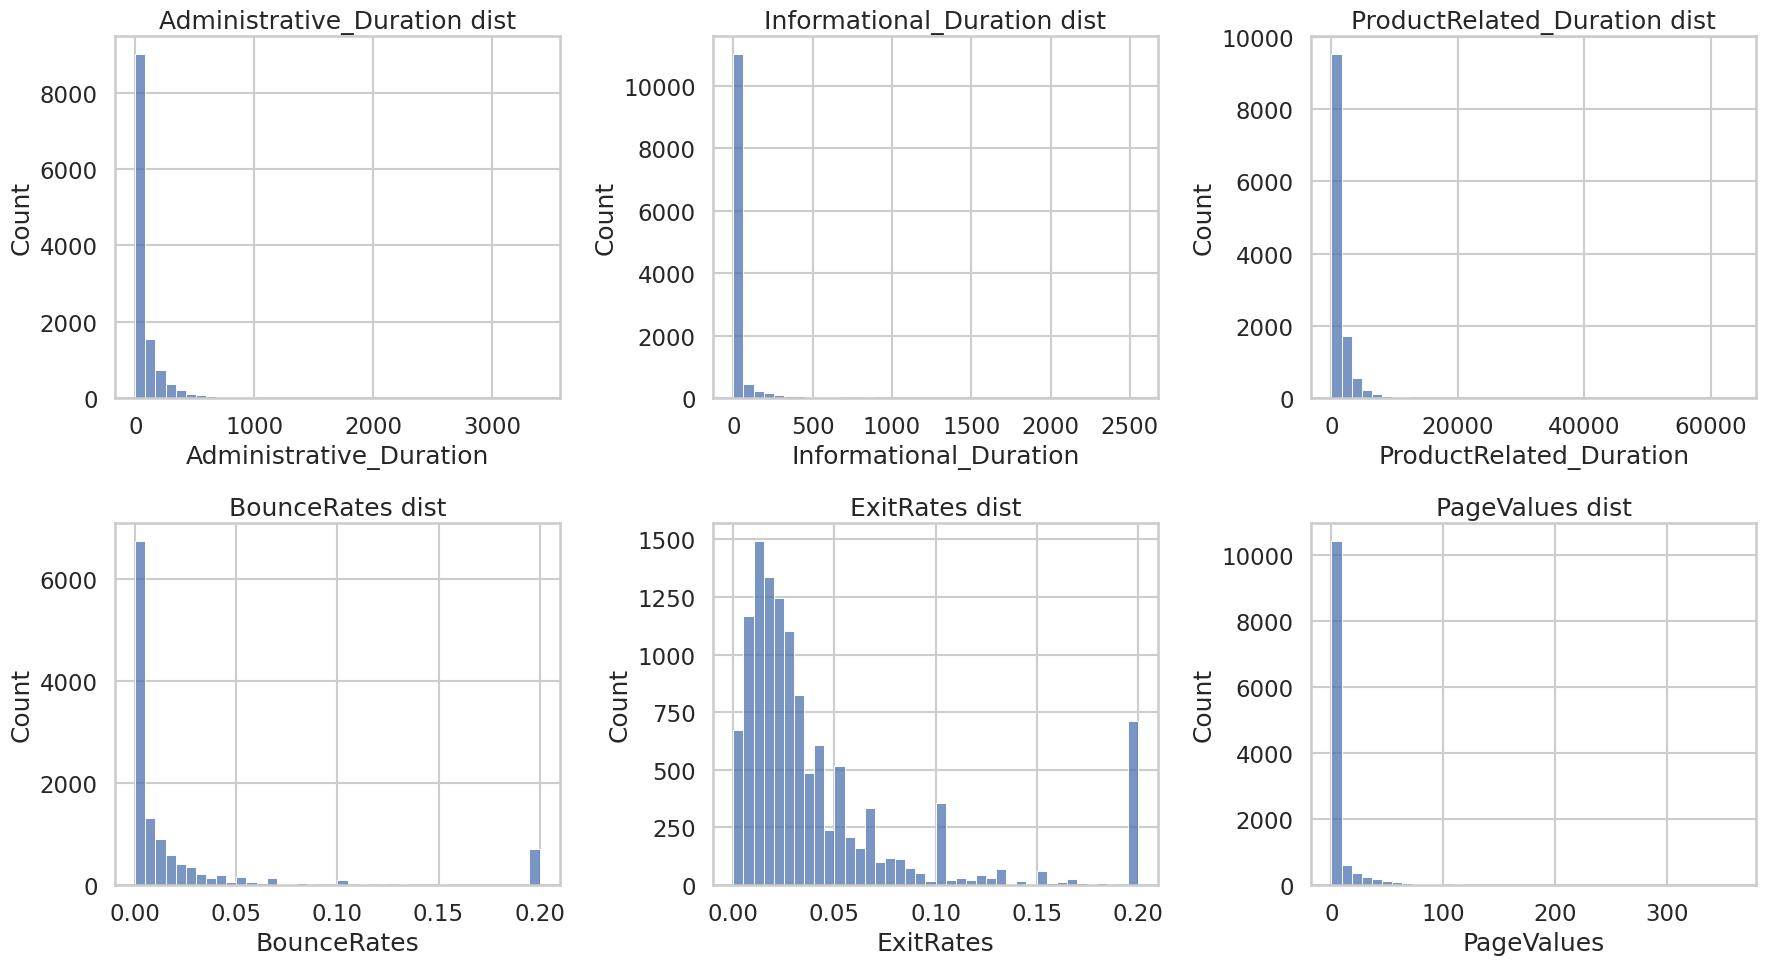

In [94]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

cols_to_check = [
    "Administrative_Duration",
    "Informational_Duration",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "PageValues",
]

for ax, col in zip(axes.flatten(), cols_to_check):
    sns.histplot(data=df_clean, x=col, bins=40, ax=ax)
    ax.set_title(f"{col} dist")

plt.tight_layout()
plt.show()

# 생각해 보기

- 어떤 변수는 평균만 보면 구조가 가려질 것 같은가?  
- 어떤 변수는 막대그래프보다 **분포 차트**가 더 적절할 것 같은가?  
- 왜도가 큰 변수에서 평균 비교만 하면 어떤 해석 오류가 생길 수 있을까?

# 8. 실무에서 자주 쓰는 보조 함수 만들기

- 실습에서는 한두 번으로 끝나지만,  
  실제 업무에서는 같은 집계와 같은 그래프를 반복해서 그리는 경우가 많습니다.
- 아래처럼 **요약 함수**와 **그림 함수**를 만들어두면 생산성이 높아집니다.

In [95]:
def summarize_binary_target_by_category(
    data: pd.DataFrame,
    category_col: str,
    target_col: str = "Revenue"
) -> pd.DataFrame:
    summary = (
        data
        .groupby(category_col, observed=False)
        .agg(
            sessions=(target_col, "size"),
            positive_count=(target_col, "sum")
        )
        .assign(
            positive_rate=lambda x: x["positive_count"] / x["sessions"]
        )
        .reset_index()
    )
    return summary


def plot_count_and_rate(
    summary_df: pd.DataFrame,
    category_col: str,
    count_col: str = "sessions",
    rate_col: str = "positive_rate",
    title_prefix: str = ""
) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    sns.barplot(data=summary_df, x=category_col, y=count_col, ax=axes[0])
    axes[0].set_title(f"{title_prefix} Count of sessions")
    axes[0].set_xlabel(category_col)
    axes[0].set_ylabel("Sessions")

    sns.barplot(data=summary_df, x=category_col, y=rate_col, ax=axes[1])
    axes[1].set_title(f"{title_prefix} Purchase Rate")
    axes[1].set_xlabel(category_col)
    axes[1].set_ylabel("Purchase Rate")
    axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))

    plt.tight_layout()
    plt.show()

# 9. 질문 1: 방문자 유형별 구매 차이는 어떠한가?

- 질문 유형: **비교 질문**
- 여기서는 반드시  
  - 절대 세션 수  
  - 구매율  
  을 함께 봐야 합니다.
- 세션 수가 많은 집단과 구매율이 높은 집단은 다를 수 있기 때문입니다.

In [96]:
visitor_summary = summarize_binary_target_by_category(df_clean, "VisitorType")
display(visitor_summary)

,VisitorType,sessions,positive_count,positive_rate
0,New_Visitor,1694,422,0.2491
1,Other,85,16,0.1882
2,Returning_Visitor,10551,1470,0.1393


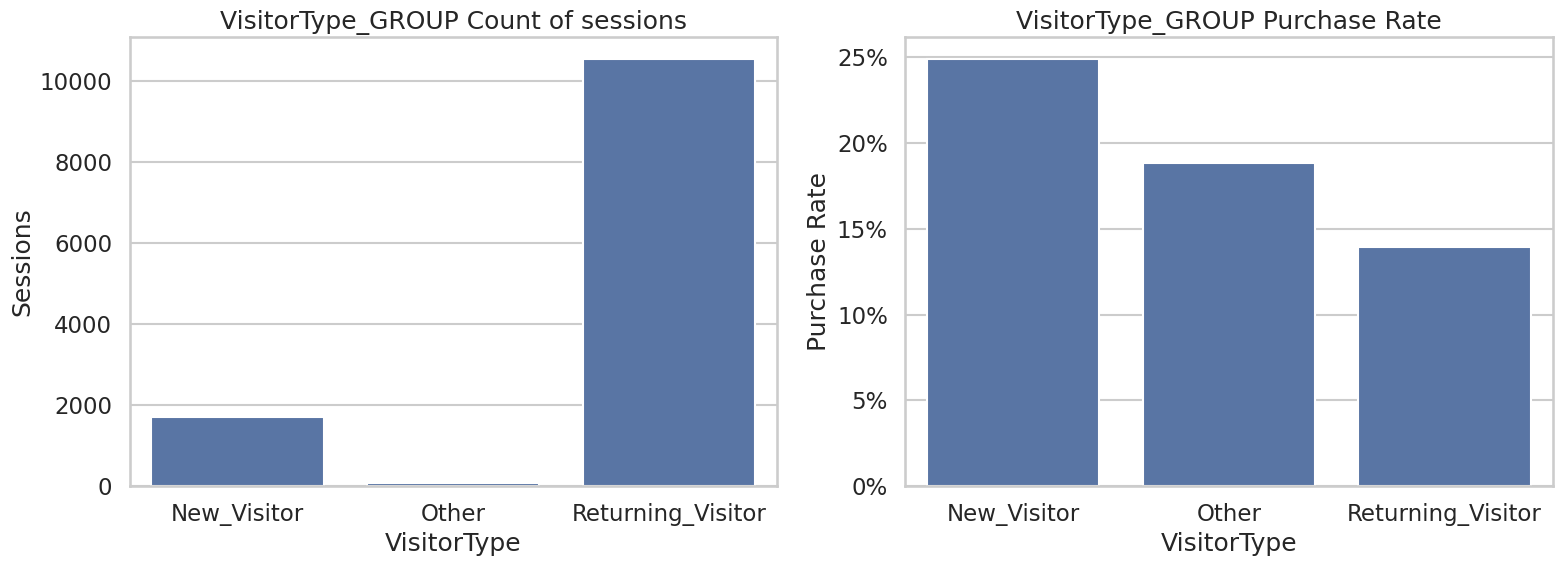

In [97]:
plot_count_and_rate(
    visitor_summary,
    category_col="VisitorType",
    title_prefix="VisitorType_GROUP"
)

# 해석 포인트

- 절대 세션 수와 구매율은 서로 다른 질문에 답합니다.
- 방문량이 많은 집단이 반드시 구매율까지 높은 것은 아닙니다.
- 실무에서는 **방문량**과 **전환율**을 분리해서 보는 습관이 중요합니다.

# 10. 질문 2: 구매 세션과 비구매 세션의 `PageValues` 분포는 다른가?

- 질문 유형: **분포 비교 질문**
- 이 경우 평균 막대그래프만으로는 부족할 수 있습니다.
- 중심 경향뿐 아니라  
  - 분산  
  - 이상치  
  - 밀도 구조  
  를 함께 확인해야 합니다.

In [98]:
pagevalues_summary = (
    df_clean
    .groupby("RevenueLabel", observed=False)["PageValues"]
    .describe()
)

display(pagevalues_summary)

,count,mean,std,min,25%,50%,75%,max
RevenueLabel,,,,,,,,
No Purchase,10422.0000,1.9760,9.0724,0.0000,0.0000,0.0000,0.0000,246.7586
Purchase,1908.0000,27.2645,35.1920,0.0000,3.6411,16.7581,38.8977,361.7637


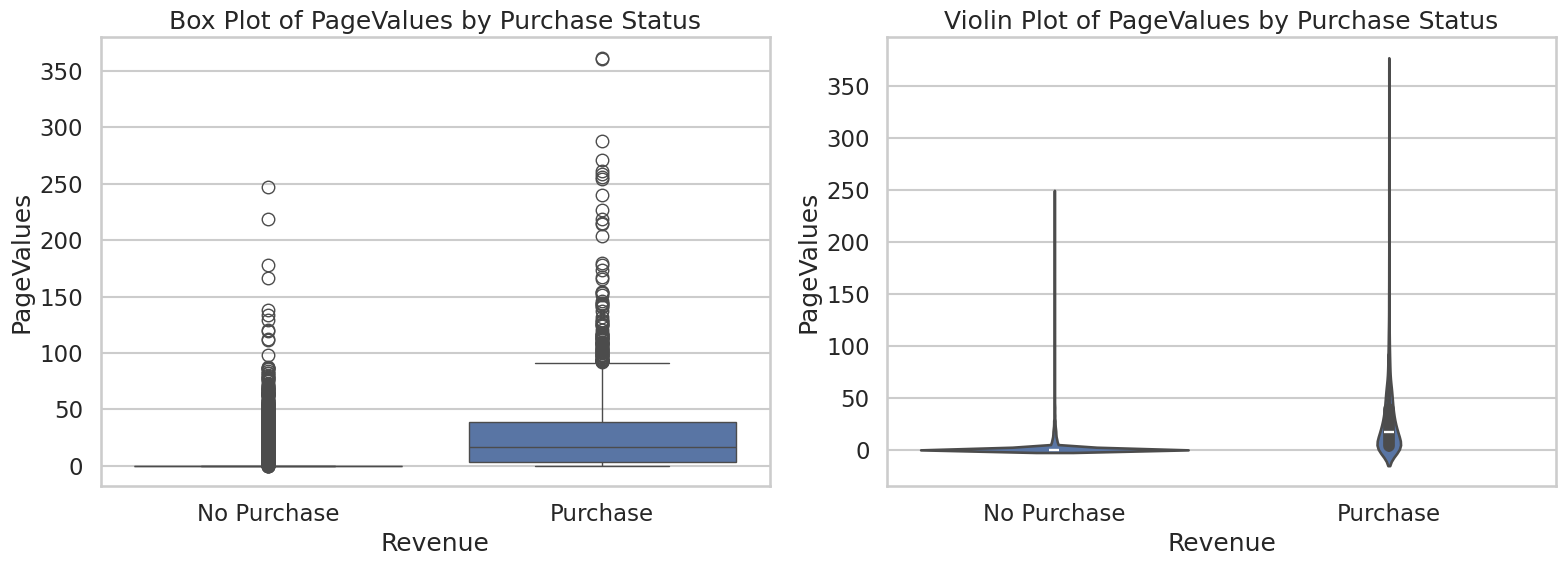

In [99]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(data=df_clean, x="RevenueLabel", y="PageValues", ax=axes[0])
axes[0].set_title("Box Plot of PageValues by Purchase Status") #구매 여부에 따른 PageValues 상자그림
axes[0].set_xlabel("Revenue")
axes[0].set_ylabel("PageValues")

sns.violinplot(data=df_clean, x="RevenueLabel", y="PageValues", inner="box", ax=axes[1])
axes[1].set_title("Violin Plot of PageValues by Purchase Status") #구매 여부에 따른 PageValues 바이올린그래프
axes[1].set_xlabel("Revenue")
axes[1].set_ylabel("PageValues")

plt.tight_layout()
plt.show()

# 생각해 보기

- 왜 이 질문에는 평균 막대그래프보다 상자그림이나 바이올린그래프가 더 적절할까?  
- 두 집단의 차이는 평균 차이인가, 분포 구조 차이인가?  
- 이상치가 많은 경우 평균 해석은 어떻게 달라질까?

# 11. 질문 3: 상품 페이지를 많이 본 세션은 실제로 체류시간도 긴가?

- 질문 유형: **관계 질문**
- 여기서는 두 수치형 변수의 관계를 봐야 하므로 산점도가 기본 후보입니다.
- 다만 점이 너무 많이 겹치면 해석이 어려워질 수 있으므로  
  `투명도`, `색상`, `축 변환`을 함께 고려합니다.

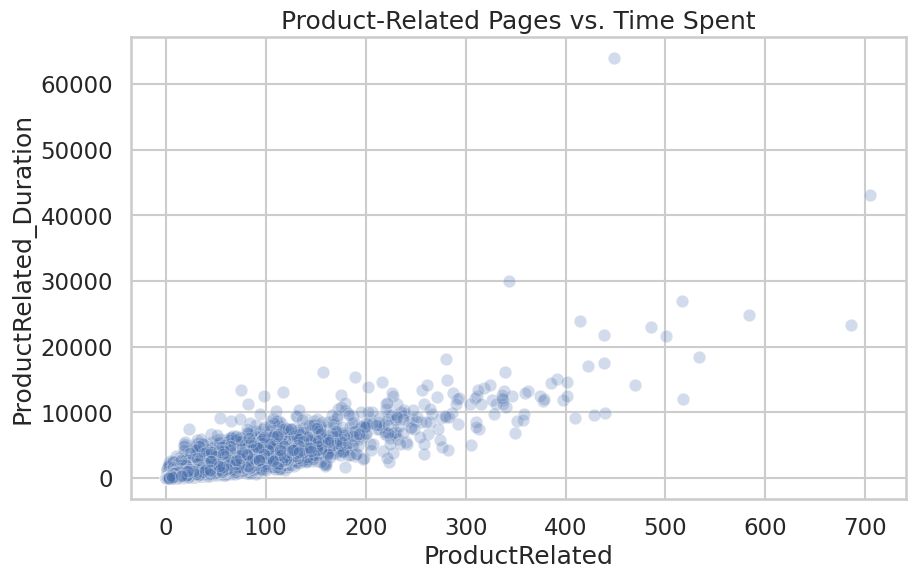

In [100]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_clean,
    x="ProductRelated",
    y="ProductRelated_Duration",
    alpha=0.25
)
plt.title("Product-Related Pages vs. Time Spent") #상품 관련 페이지 수와 체류시간의 관계
plt.xlabel("ProductRelated")
plt.ylabel("ProductRelated_Duration")
plt.show()

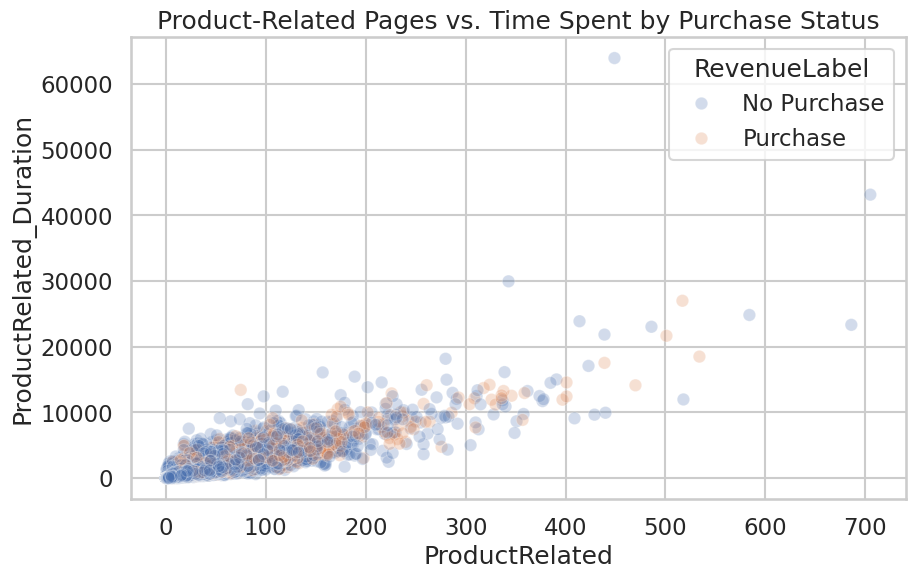

In [101]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_clean,
    x="ProductRelated",
    y="ProductRelated_Duration",
    hue="RevenueLabel",
    alpha=0.25
)
plt.title("Product-Related Pages vs. Time Spent by Purchase Status") #상품 관련 페이지 수와 체류시간의 관계 (구매 여부 색상 구분)
plt.xlabel("ProductRelated")
plt.ylabel("ProductRelated_Duration")
plt.show()

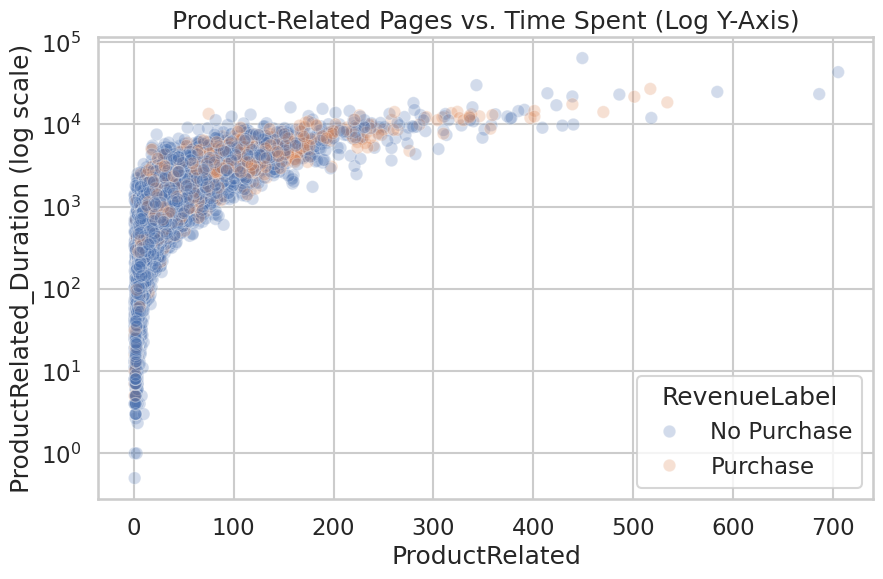

In [102]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_clean,
    x="ProductRelated",
    y="ProductRelated_Duration",
    hue="RevenueLabel",
    alpha=0.25
)
plt.yscale("log")
plt.title("Product-Related Pages vs. Time Spent (Log Y-Axis)") #상품 관련 페이지 수와 체류시간의 관계 (세로축 로그 변환)
plt.xlabel("ProductRelated")
plt.ylabel("ProductRelated_Duration (log scale)")
plt.show()

# 해석 포인트

- 점이 겹칠 때는 `투명도`를 조정하는 것이 중요합니다.
- 구매 여부를 색으로 구분하면, 전체 구조와 집단 차이를 동시에 볼 수 있습니다.
- 오른쪽 긴 꼬리 분포가 심한 경우, 로그 변환은 패턴을 더 읽기 쉽게 만들 수 있습니다.
- 단, 축 변환은 **데이터를 바꾸는 것**이 아니라 **읽는 방식**을 바꾸는 선택이라는 점을 기억해야 합니다.

# 12. 질문 4: 월별로 세션 수와 구매율은 어떻게 다른가?

- 질문 유형: **비교 질문 + 순서가 있는 범주 비교**
- `Month`는 문자열이지만 순서가 중요하므로,  
  단순 사전순이 아니라 월 순서를 반영해야 합니다.

In [103]:
month_summary = summarize_binary_target_by_category(df_clean, "Month")
display(month_summary)

,Month,sessions,positive_count,positive_rate
0,Feb,184,3,0.0163
1,Mar,1907,192,0.1007
2,May,3364,365,0.1085
3,June,288,29,0.1007
4,Jul,432,66,0.1528
5,Aug,433,76,0.1755
6,Sep,448,86,0.1920
7,Oct,549,115,0.2095
8,Nov,2998,760,0.2535
9,Dec,1727,216,0.1251


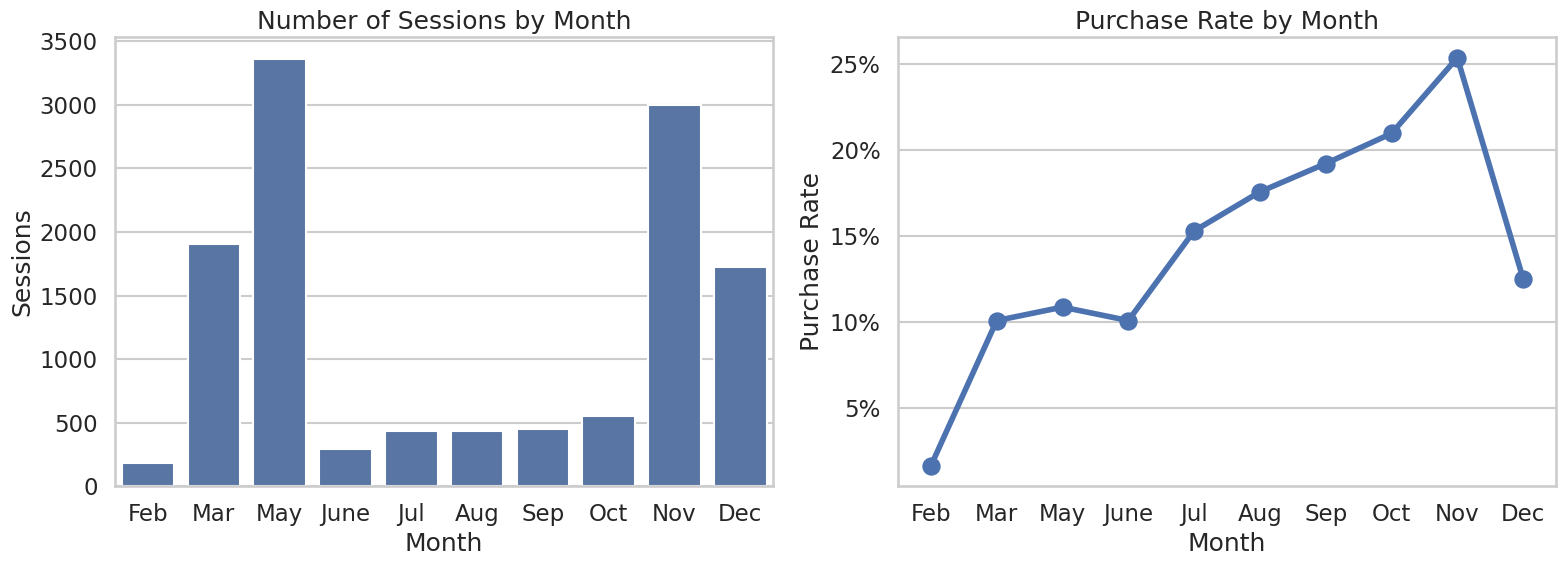

In [104]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=month_summary, x="Month", y="sessions", ax=axes[0])
axes[0].set_title("Number of Sessions by Month")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Sessions")

sns.pointplot(data=month_summary, x="Month", y="positive_rate", ax=axes[1])
axes[1].set_title("Purchase Rate by Month")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Purchase Rate")
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))

plt.tight_layout()
plt.show()

# 해석 포인트

- 막대그래프는 절대량 비교에 유리합니다.
- 점그래프는 **순서가 있는 범주**를 비교할 때 간결하게 쓰기 좋습니다.
- 같은 월별 데이터라도 세션 수와 구매율은 서로 다른 의미를 가지므로 분리해서 보는 것이 좋습니다.

# 13. 질문 5: 방문자 유형에 따라 `BounceRates` 분포가 다른가?

- 질문 유형: **집단별 분포 비교**
- 이 질문에서는 평균 비교만으로는 부족할 수 있으므로  
  요약 구조와 일부 원자료를 함께 보는 방식을 사용해볼 수 있습니다.

In [105]:
bounce_summary = (
    df_clean
    .groupby("VisitorType", observed=False)["BounceRates"]
    .describe()
)
display(bounce_summary)

,count,mean,std,min,25%,50%,75%,max
VisitorType,,,,,,,,
New_Visitor,1694.0000,0.0053,0.0263,0.0000,0.0000,0.0000,0.0000,0.2000
Other,85.0000,0.0386,0.0784,0.0000,0.0000,0.0000,0.0000,0.2000
Returning_Visitor,10551.0000,0.0248,0.0503,0.0000,0.0000,0.0053,0.0200,0.2000


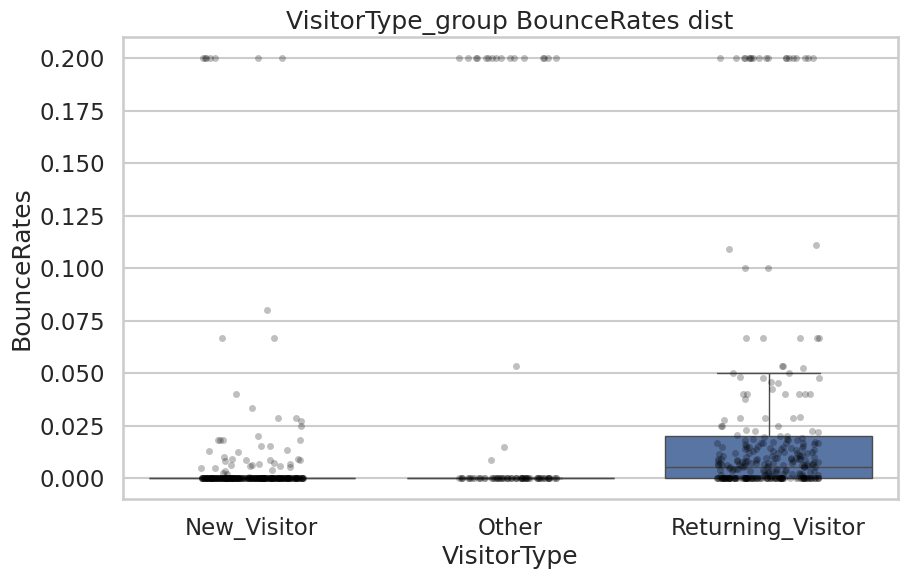

In [106]:
sample_df = (
    df_clean
    .groupby("VisitorType", observed=False, group_keys=False)
    .apply(lambda x: x.sample(min(len(x), 300), random_state=42))
)

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_clean, x="VisitorType", y="BounceRates", showfliers=False)
sns.stripplot(
    data=sample_df,
    x="VisitorType",
    y="BounceRates",
    color="black",
    alpha=0.25,
    jitter=0.2
)
plt.title("VisitorType_group BounceRates dist")#VT별 분포
plt.xlabel("VisitorType")
plt.ylabel("BounceRates")
plt.show()

# 해석 포인트

- 상자그림은 분포 요약을 보여줍니다.
- 점 일부를 함께 겹치면 실제 관측치의 흩어짐을 더 직관적으로 볼 수 있습니다.
- 실무에서도 **요약 구조 + 일부 원자료**를 함께 제시하는 방식은 매우 유용합니다.

# 14. 범주형 변수별 구매율을 빠르게 확인하는 자동 요약

- 범주형 변수가 여러 개 있을 때,  
  매번 손으로 집계하지 않고 반복 가능한 형태로 확인하는 것이 실무적으로 유리합니다.

In [107]:
for col in ["VisitorType", "WeekendLabel", "Month", "Browser", "TrafficType"]:
    print(f"\n===== {col} =====")
    display(summarize_binary_target_by_category(df_clean, col).sort_values("positive_rate", ascending=False).head(10))


===== VisitorType =====


,VisitorType,sessions,positive_count,positive_rate
0,New_Visitor,1694,422,0.2491
1,Other,85,16,0.1882
2,Returning_Visitor,10551,1470,0.1393



===== WeekendLabel =====


,WeekendLabel,sessions,positive_count,positive_rate
1,Weekend,2868,499,0.1740
0,Weekday,9462,1409,0.1489



===== Month =====


,Month,sessions,positive_count,positive_rate
8,Nov,2998,760,0.2535
7,Oct,549,115,0.2095
6,Sep,448,86,0.1920
5,Aug,433,76,0.1755
4,Jul,432,66,0.1528
9,Dec,1727,216,0.1251
2,May,3364,365,0.1085
3,June,288,29,0.1007
1,Mar,1907,192,0.1007
0,Feb,184,3,0.0163



===== Browser =====


,Browser,sessions,positive_count,positive_rate
11,12,10,3,0.3000
12,13,61,16,0.2623
9,10,163,32,0.1963
4,5,467,86,0.1842
3,4,736,130,0.1766
10,11,6,1,0.1667
7,8,135,21,0.1556
1,2,7961,1223,0.1536
0,1,2462,365,0.1483
6,7,49,6,0.1224



===== TrafficType =====


,TrafficType,sessions,positive_count,positive_rate
15,16,3,1,0.3333
6,7,40,12,0.3000
7,8,343,95,0.2770
19,20,198,50,0.2525
1,2,3913,847,0.2165
4,5,260,56,0.2154
9,10,450,90,0.2000
10,11,247,47,0.1903
3,4,1069,165,0.1543
13,14,13,2,0.1538


# 15. 실습 과제 제안

### 과제 1
- `VisitorType`별 구매율을 비교하시오.
- 세션 수와 구매율을 각각 시각화하시오.
- 두 차트가 왜 다른 메시지를 줄 수 있는지 3문장으로 설명하시오.

### 과제 2
- `PageValues`를 구매 여부에 따라 비교하시오.
- 평균 막대그래프와 분포 차트를 각각 그리시오.
- 어느 차트가 더 적절한지 이유를 쓰시오.

### 과제 3
- `ProductRelated`와 `ProductRelated_Duration`의 관계를 시각화하시오.
- `투명도`, `색상`, `축 변환` 중 최소 2개를 적용하시오.
- 적용 전후 해석이 어떻게 달라지는지 쓰시오.

# 16. 해석 문장 템플릿

- **관찰**: 무엇이 보이는가  
- **구조**: 차이가 평균 수준인가, 분포 수준인가  
- **한계**: 무엇은 아직 말할 수 없는가  
- **의미**: 그래서 어떤 판단이 가능한가  

### 예시
- 재방문자 집단은 신규 방문자 집단보다 구매율이 높게 나타난다.  
- 다만 집단 간 세션 수 차이가 존재하므로 구매율과 절대량을 함께 봐야 한다.  
- 따라서 재방문자 관리 전략은 유효할 수 있지만, 신규 방문자 유입 규모와 분리해서 해석해야 한다.

# 17. 마무리 정리

- 이 데이터는 **세션 단위 전자상거래 로그 데이터**입니다.
- 차트를 그리기 전에  
  - 질문 유형  
  - 관측 단위  
  - 변수 역할  
  - 집계 수준  
  을 먼저 정리해야 합니다.
- 좋은 차트는 예쁜 차트가 아니라,  
  **질문에 가장 적절하게 답하는 차트**입니다.
- 다음 차시에서는 여기서 더 나아가  
  **집계, 변환, 다변량 구조, 분포와 불확실성**을 더 깊게 다룰 수 있습니다.